# Environment

## Imports

In [1]:
import pyranges1 as pr
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as colors

## Global variables

## Load data

Load peaks for each method and the SCREEN peaks

In [2]:
screen = pr.read_bed("data/peaks/screen.bed")
atac = pr.read_bed("data/peaks/atac_consensus_peaks.bed")
gex = pr.read_bed("data/peaks/gex_consensus_peaks.bed")
lvl3 = pr.read_bed("data/peaks/newlvl3_consensus_peaks.bed")
lvl5 = pr.read_bed("data/peaks/newlvl5_consensus_peaks.bed")
original = pr.read_bed("data/peaks/original_consensus_peaks.bed")

In [3]:
peaks = {
    "screen": screen,
    "atac": atac,
    "gex": gex,
    "lvl3": lvl3,
    "lvl5": lvl5,
    "original": original
}

for key, df in peaks.items():
    if key != "screen":
        df["Center"] = df["Start"] + (df["End"] - df["Start"]) // 2
        df["celltypes"] = df["Name"].str.replace(r'_peak_\d+[a-z]*', '', regex=True).apply(lambda x: ",".join(set(x.split(","))))
        df["ct_count"] = df["celltypes"].apply(lambda x: int(len(set(x.split(",")))))

In [4]:
peaks["screen"].head()

,Chromosome,Start,End,Name,Score,Strand
0,chr1,10033,10250,EH38D4327497,EH38E2776516,pELS
1,chr1,10385,10713,EH38D4327498,EH38E2776517,pELS
2,chr1,16097,16381,EH38D6144701,EH38E3951272,CA-CTCF
3,chr1,17343,17642,EH38D6144702,EH38E3951273,CA-TF
4,chr1,29320,29517,EH38D6144703,EH38E3951274,CA


Load cell type annotations

In [5]:
annotations = {
    "lvl5": pd.read_csv("data/annotations/we_new_lvl5.csv"),
    "lvl3": pd.read_csv("data/annotations/we_new_lvl3.csv"),
}

In [6]:
annotations["lvl5"].head()

,sample_id,barcode,celltype
0,WS_wEMB13386878,ATGGACAAGACAGGTA-1,chondrocyte precursor
1,WS_wEMB13386878,TCAAGTATCTGTGAGT-1,yolk sac-derived TREM2+ macrophage
2,WS_wEMB13386878,CGGCTCACAGTTATGT-1,early endothelium
3,WS_wEMB13386878,ATTTGCGCACTAAGCC-1,fibroblast progenitors PDGFRA+ZIC1+FIBIN+
4,WS_wEMB13386878,CCTTCAATCAAGCTTA-1,monocyte


# Compare peaks

## Peak length distribution

Peaks that we called with `pyCistopic` all have a length of 500bp, which is the default value for the `peak_extension` parameter. Let's take a look at the length distribution of the SCREEN peaks

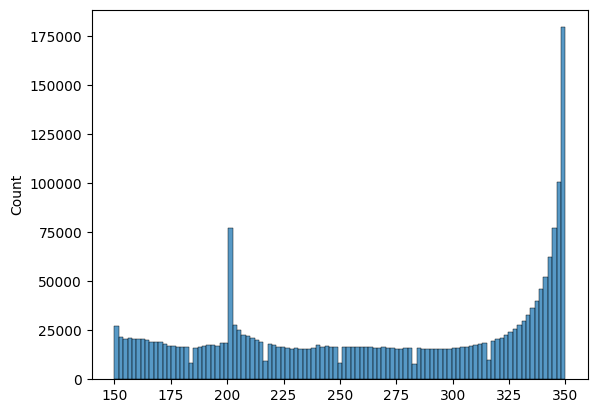

In [7]:
sns.histplot(screen.End - screen.Start)
plt.show()

## Peak counts

The number of peaks called by each approach is as follows

Text(0.5, 1.0, 'Number of peaks per chromosome for each approach')

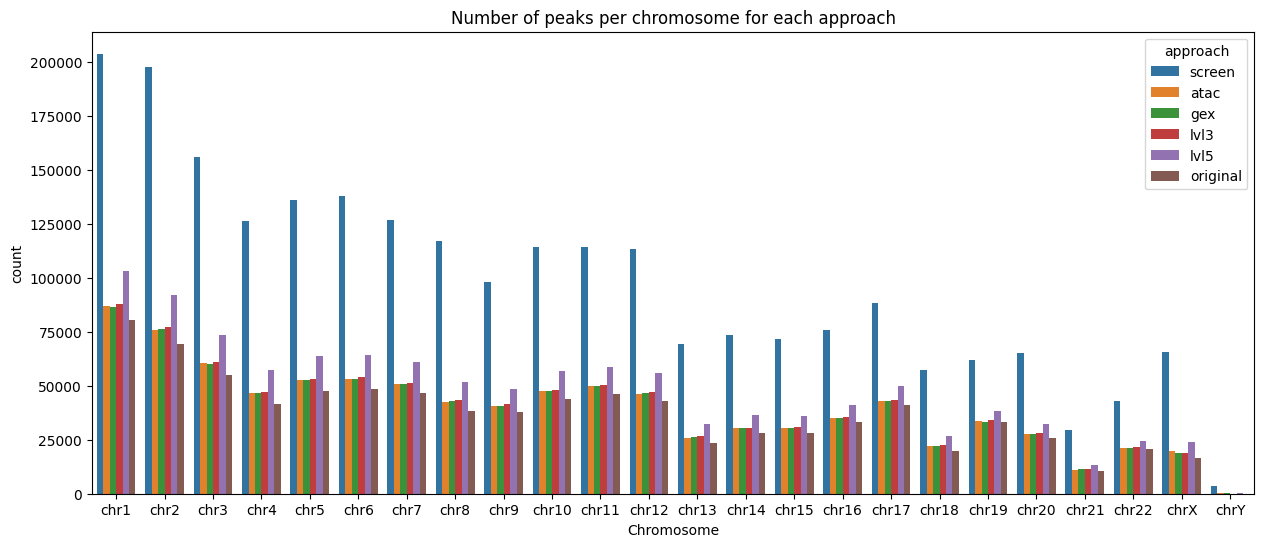

In [8]:
fig, ax = plt.subplots(figsize=(15, 6))

# Count the number of peaks per chromosome for each approach
peak_counts_bychr = pd.concat([peaks[key].Chromosome.value_counts().to_frame(name=key) for key in peaks.keys()], axis=1)
peak_counts_bychr_unstacked = (
    peak_counts_bychr
    .unstack()
    .to_frame(name="count")
    .reset_index()
    .rename(columns={"level_0": "approach"})
)

# The chromosomes are currently sorted in alphanumeric order, which is not ideal. Let's sort them in natural order
chrom_order = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY']
cat_type = pd.CategoricalDtype(categories=chrom_order, ordered=True)
peak_counts_bychr_unstacked['Chromosome'] = peak_counts_bychr_unstacked['Chromosome'].astype(cat_type)
peak_counts_bychr_unstacked = peak_counts_bychr_unstacked.sort_values('Chromosome')

sns.barplot(
    peak_counts_bychr_unstacked,
    x="Chromosome",
    y="count",
    hue="approach",
    hue_order=["screen", "atac", "gex", "lvl3", "lvl5", "original"],
    ax=ax
)

ax.set_title("Number of peaks per chromosome for each approach")

We can notice that the number of peaks called for `lvl5` annotation is higher compared to other approaches. We will need to investigate if those peaks are actually relevant. On the other hand, we can see that the number of peaks for separate chromosomes is highly correlated between the different approaches, which is reassuring

<Axes: >

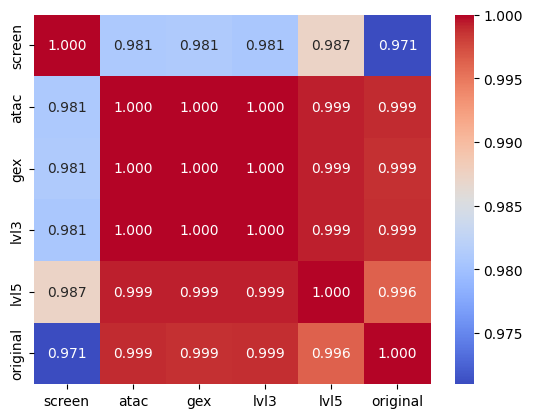

In [9]:
sns.heatmap(peak_counts_bychr.corr(), annot=True, cmap="coolwarm", fmt=".3f")

### Peak overlaps

Now we can look at how many peaks from each set overlap with peaks from the other sets, using a minimum overlap threshold of 30 bp

In [10]:
overlap_threshold = 30
counts = list()
fractions = list()
overlap_lengths = list()


for key1, df1 in tqdm(peaks.items()):
    key1_counts = list()
    key1_fractions = list()
    key1_overlap_lengths = list()
    key1_overlap_fractions = list()
    for key2, df2 in peaks.items():
        if key1 == key2:
            key1_counts.append(df1.shape[0])
            key1_fractions.append(1)
            key1_overlap_lengths.append((df1.End - df1.Start).mean())
            key1_overlap_fractions.append(1)
        else:
            # find overlaps between df1 and df2
            overlaps = df1.intersect_overlaps(df2)
            # filter overlaps by length
            overlaps["length"] = overlaps.End - overlaps.Start
            overlaps = overlaps[overlaps["length"] >= overlap_threshold]
            # remove duplicate overlaps (i.e. multiple peaks in df2 overlapping the same peak in df1)
            overlaps = overlaps[~overlaps.index.duplicated()]
            # save the number of overlaps and the fraction of peaks in df1 that overlap with peaks in df2
            key1_counts.append(overlaps.shape[0])
            key1_fractions.append(overlaps.shape[0] / df1.shape[0])
            key1_overlap_lengths.append((overlaps.End - overlaps.Start).mean())
    counts.append(key1_counts)
    fractions.append(key1_fractions)
    overlap_lengths.append(key1_overlap_lengths)

# create a dataframe from the counts and fractions
counts_df = pd.DataFrame(counts, columns=peaks.keys(), index=peaks.keys())
fractions_df = pd.DataFrame(fractions, columns=peaks.keys(), index=peaks.keys())
overlap_lengths_df = pd.DataFrame(overlap_lengths, columns=peaks.keys(), index=peaks.keys())

  0%|          | 0/6 [00:00<?, ?it/s]

First, let's look at the number and fraction of peaks that overlap between each pair of approaches

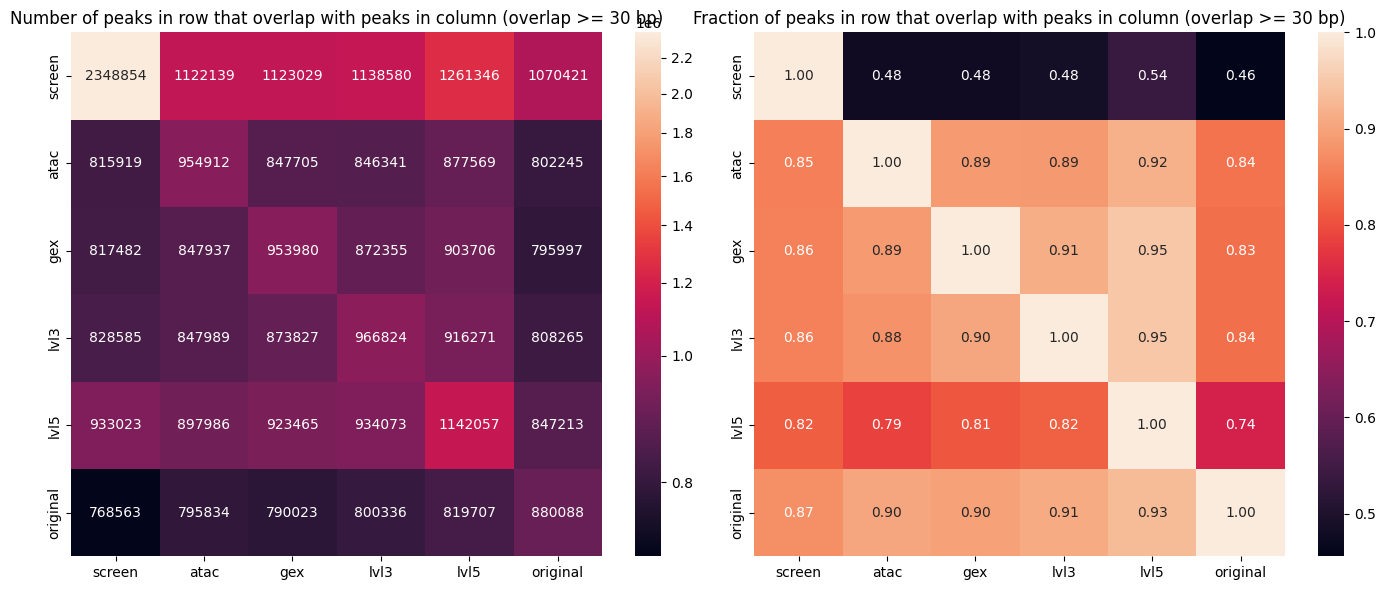

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
norm = colors.PowerNorm(0.5, vmin=None, vmax=None, clip=False)

sns.heatmap(counts_df, annot=True, fmt="d", ax=ax1, norm=norm)
sns.heatmap(fractions_df, annot=True, fmt=".2f", ax=ax2)

ax1.set_title(f"Number of peaks in row that overlap with peaks in column (overlap >= {overlap_threshold} bp)")
ax2.set_title(f"Fraction of peaks in row that overlap with peaks in column (overlap >= {overlap_threshold} bp)")
plt.tight_layout()
plt.show()

Second, let's take a look at the distributions of the lengths of the overlaps between peaks from each pair of approaches

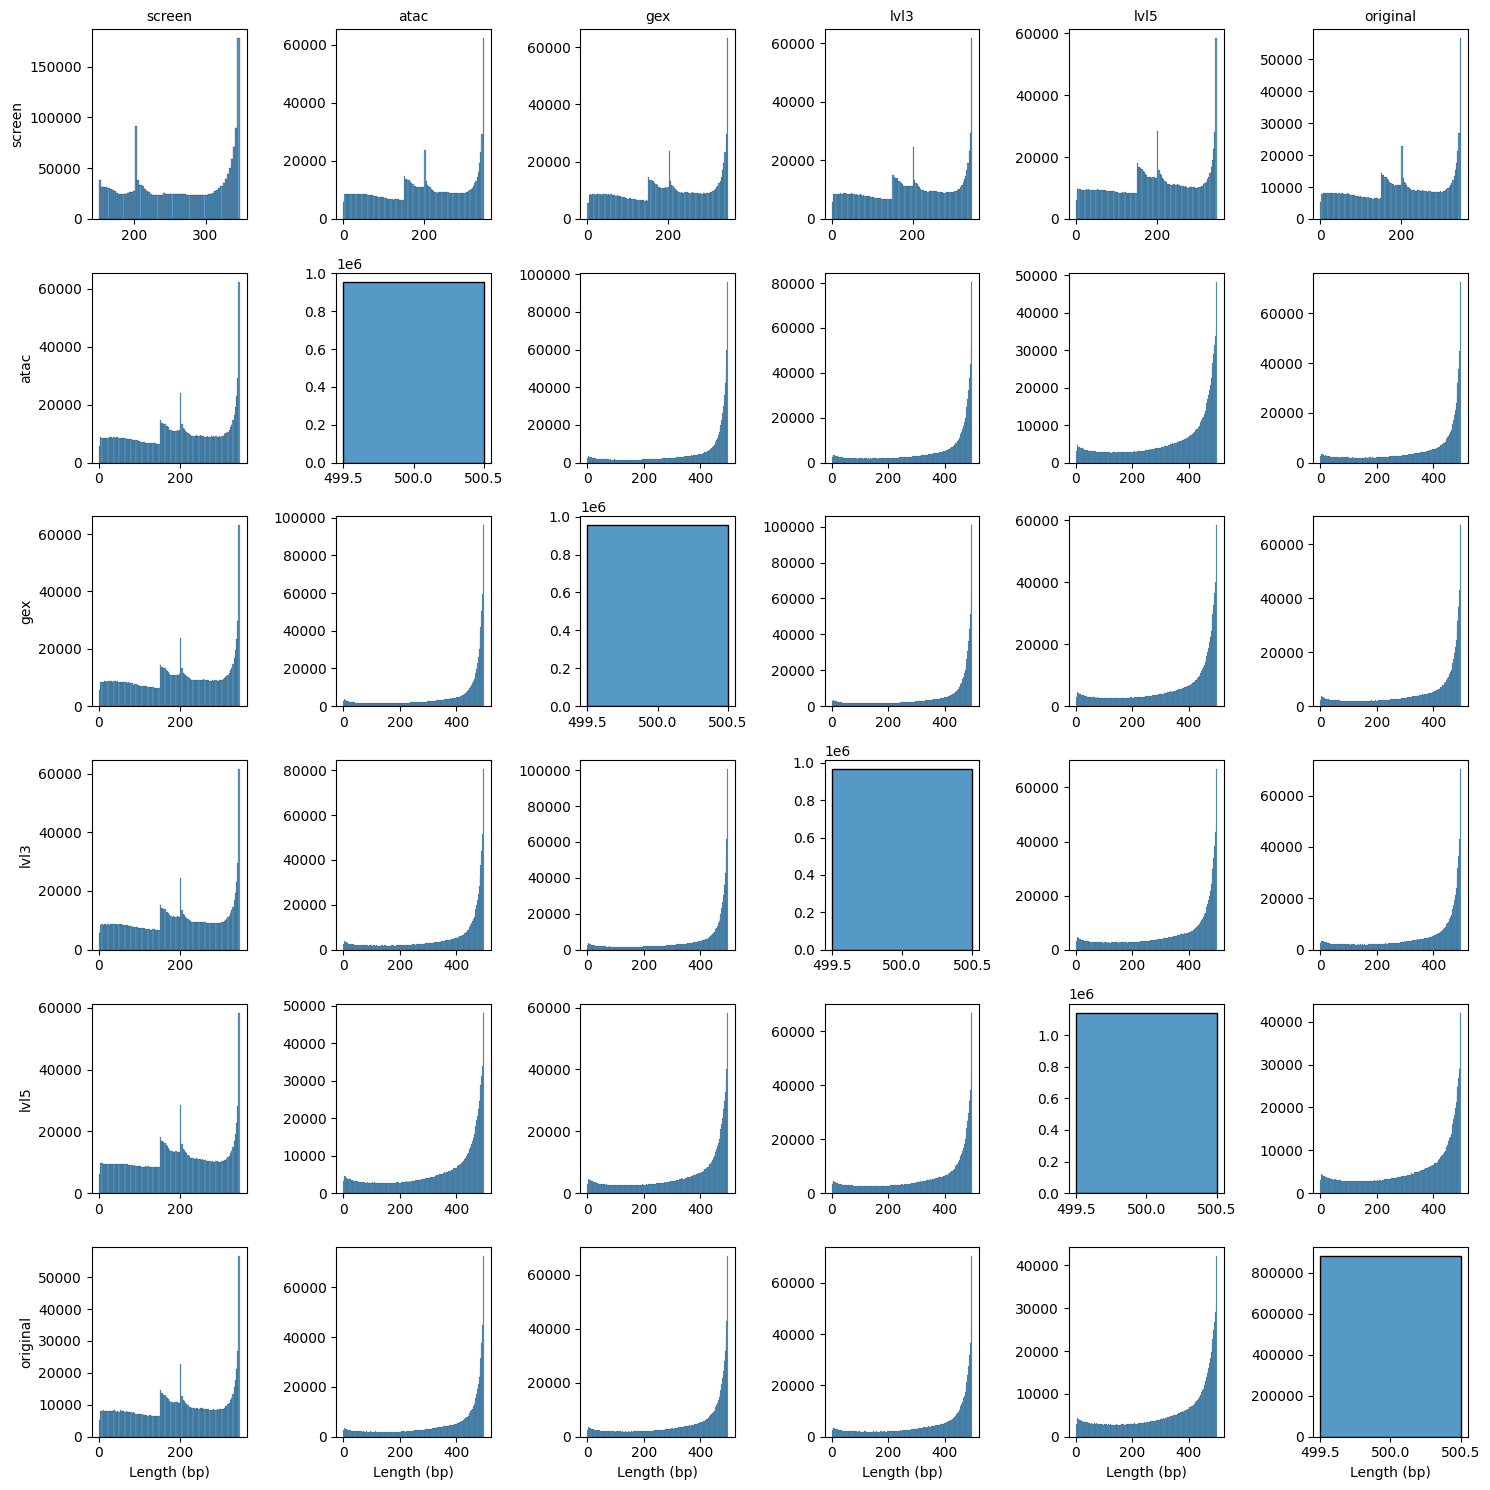

In [12]:
fig, axes = plt.subplots(len(peaks), len(peaks), figsize=(15, 15))
keys = list(peaks.keys())

for i, (key1, df1) in enumerate(peaks.items()):
    for j, (key2, df2) in enumerate(peaks.items()):
        ax = axes[i, j]
        
        # find overlaps between df1 and df2
        if key1 == key2:
            overlap_lengths = df1.End - df1.Start
            bins = 1 if i != 0 else np.arange(150, 350, 3)
        else:
            overlaps = df1.intersect_overlaps(df2)
            overlaps["length"] = overlaps.End - overlaps.Start
            overlap_lengths = overlaps["length"]
            bins = np.arange(0, 350, 3) if i == 0 or j == 0 else np.arange(0, 500, 3)
        
        # plot the distribution of overlap lengths
        sns.histplot(overlap_lengths, ax=ax, bins=bins)

        # only show axis labels on edges
        ax.set_xlabel("Length (bp)" if i == len(peaks) - 1 else "")
        ax.set_ylabel("Count" if j == 0 else "")
        
        # only show row/col headers on edges
        if i == 0:
            ax.set_title(keys[j], fontsize=10)
        else:
            ax.set_title("")
        if j == 0:
            ax.set_ylabel(keys[i], fontsize=10)

plt.tight_layout()